# Détection de Fake News par Apprentissage Automatique

---

## 1. Contexte Général

L'apprentissage automatique constitue aujourd'hui l'un des piliers majeurs de l'intelligence artificielle. Il désigne l'ensemble des méthodes permettant à un système informatique d'apprendre automatiquement à partir de données, sans avoir besoin d'être explicitement programmé pour chaque tâche. En s'appuyant sur des algorithmes capables d'identifier des motifs, de généraliser à partir d'exemples et de faire des prédictions, le machine learning est désormais au cœur de nombreuses applications modernes : vision par ordinateur, reconnaissance vocale, systèmes de recommandation, cybersécurité et traitement automatique du langage naturel (NLP).

Les progrès récents en puissance de calcul, la disponibilité massive de données numériques et l'émergence de modèles plus performants ont largement contribué à l'essor de ces techniques. En particulier, le traitement automatique du langage naturel a connu des avancées significatives, permettant aux machines d'analyser, de comprendre et d'interpréter le langage humain avec une précision croissante.

---

## 2. Problématique : La Menace des Fake News

À l'ère du numérique, l'information joue un rôle central dans la formation de l'opinion publique et dans la prise de décision individuelle et collective. Cependant, l'explosion des réseaux sociaux et des plateformes de diffusion de contenu a également favorisé la propagation rapide de fausses informations, communément appelées *fake news*.

Ces contenus trompeurs, souvent conçus pour manipuler, désinformer ou influencer des comportements, se diffusent à grande échelle et à grande vitesse. La prolifération des fake news représente un enjeu sociétal majeur :

- **Confiance érodée** : elle affecte la crédibilité des médias et des institutions
- **Instabilité politique** : elle menace les processus démocratiques et les élections
- **Santé publique** : elle propage des informations médicales dangereuses
- **Impact économique** : elle peut influencer les marchés financiers et les comportements des consommateurs

Face à l'ampleur du volume d'informations diffusées quotidiennement, les méthodes traditionnelles de vérification manuelle (*fact-checking*) deviennent insuffisantes. Cette réalité rend nécessaire le recours à des solutions automatisées capables de traiter des milliers d'articles en temps réel.

---

## 3. Objectif du Projet

L'objectif principal de ce projet est de concevoir un système automatisé capable de détecter et de distinguer les fausses nouvelles des informations vérifiées. Ce système repose sur des méthodes d'apprentissage automatique appliquées à l'analyse de textes, afin d'évaluer la crédibilité du contenu et d'assister le processus de détection de la désinformation.

Plus précisément, le projet vise à :

1. **Analyser** le contenu textuel des articles de presse
2. **Explorer** les données pour identifier les patterns distinctifs entre vraies et fausses nouvelles
3. **Prétraiter** les textes pour éliminer le bruit et normaliser le contenu
4. **Vectoriser** les données textuelles en représentations numériques exploitables
5. **Entraîner et comparer** plusieurs modèles de classification supervisée
6. **Évaluer** la robustesse des modèles à l'aide de métriques adaptées

---

## 4. Jeu de Données

### 4.1 Choix du Dataset

La réalisation de ce projet repose sur le dataset **Fake and Real News** disponible sur Kaggle. Ce choix a été motivé par plusieurs critères :

| Critère | Justification |
|---------|---------------|
| **Taille suffisante** | Avec près de 45 000 articles, le dataset offre assez de données pour entraîner des modèles robustes et obtenir des résultats statistiquement significatifs |
| **Distribution équilibrée** | La répartition quasi-égale entre vraies (47.7%) et fausses (52.3%) nouvelles évite les biais liés au déséquilibre des classes |
| **Données annotées** | Les labels (Real/Fake) sont déjà fournis, permettant un apprentissage supervisé direct |
| **Qualité du contenu** | Les articles proviennent de sources identifiables avec un texte complet (pas seulement des titres) |
| **Accessibilité** | Dataset public et libre d'accès pour la reproductibilité des expériences |

### 4.2 Description du Dataset

| Attribut | Description |
|----------|-------------|
| **Source** | Kaggle - Fake and Real News Dataset |
| **Taille totale** | 44 898 articles |
| **Vraies nouvelles** | 21 417 articles (47.7%) |
| **Fausses nouvelles** | 23 481 articles (52.3%) |
| **Colonnes disponibles** | `title`, `text`, `subject`, `date` |
| **Variable cible** | Classification binaire (Real = 0, Fake = 1) |

### 4.3 Structure des Données

Le dataset est initialement divisé en deux fichiers CSV distincts :
- `True.csv` : contient les articles vérifiés comme authentiques
- `Fake.csv` : contient les articles identifiés comme faux

Cette séparation facilite l'attribution des labels lors de la fusion des données.




## **Implémentation**

### **Étape 1: Import des Librairies**

Le projet s’appuie sur plusieurs librairies telles que Pandas et NumPy pour la manipulation des données, NLTK et spaCy pour le prétraitement du texte, Scikit-learn et XGBoost pour l’entraînement et l’évaluation des modèles de classification, ainsi que Matplotlib, Seaborn et Plotly pour la visualisation des résultats.

In [1]:
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt')
nltk.download('stopwords')
import spacy
nlp = spacy.load("en_core_web_sm")
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize , sent_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import  ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from math import ceil
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /var/lib/khenn/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /var/lib/khenn/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### **Étape 2: Chargement et prétraitement des données**

Cette étape consiste à importer et nettoyer les données. Cela inclut la vérification de l’absence de valeurs
manquantes et la déduplication afin de garantir l’intégrité du jeu de données. Le nettoyage du texte est effectué à 
l’aide d’une fonction spécifique qui supprime les caractères spéciaux, les liens, les espaces superflus et les mots 
inutiles pour le classement (stopwords), puis applique une lemmatisation via spaCy. Cette transformation normalise le
texte, réduit sa dimensionnalité et facilite l’apprentissage des modèles de classification.

Pour mieux comprendre la nature des données, des statistiques descriptives sont calculées (nombre de caractères, de mots 
et de phrases par article) et visualisées. Des graphiques tels que pairplots pour les variables numériques, diagrammes 
circulaires pour la distribution des sujets et barplots pour le comptage des articles vrais et faux sont utilisés. Ces 
visualisations permettent d’identifier des tendances, des déséquilibres et des caractéristiques distinctives entre les 
classes, ce qui est crucial pour guider le choix des modèles et des méthodes de prétraitement.

In [2]:
df_Fake = pd.read_csv('./data/Fake.csv')
df_True = pd.read_csv('./data/True.csv')

In [3]:
df_Fake.sample(5)

,title,text,subject,date
12345,#HAMILTON Star Makes Jokes On Twitter About “B...,When not lecturing the Trump Administration fo...,politics,"Nov 20, 2016"
7942,Someone Just Turned The Lights Off On Donald ...,It looks as though someone just finally had en...,News,"February 21, 2016"
19378,MEXICAN ILLEGAL ALIEN DEPORTED 19 Times Arrest...,BUILD THAT WALL [ ] And when Mexico sends its ...,left-news,"Dec 30, 2016"
5323,Nate Silver Has A Frightening Prediction For ...,If sane Americans have done one stupid thing o...,News,"July 25, 2016"
18643,DEMOCRAT SENATOR Makes Up FAKE Anti-Trump Stor...,The Democrats are lying all over the place alo...,left-news,"May 11, 2017"


In [4]:
df_True.sample(5)

,title,text,subject,date
11195,Many 'lost' voters say they have found their c...,WASHINGTON/NEW YORK (Reuters) - Ted Wade hasn’...,politicsNews,"January 17, 2016"
17041,UK Brexit bill not scheduled for debate in par...,LONDON (Reuters) - Britain s parliament will n...,worldnews,"October 19, 2017"
6622,"Aghast at Iran's Syria gains, Gulf Arabs see p...","RIYADH (Reuters) - “Where are you, Oh Arabs, O...",politicsNews,"December 20, 2016"
2506,White House domestic advisers take lead on ref...,WASHINGTON (Reuters) - The White House Domesti...,politicsNews,"July 26, 2017"
8313,Puerto Rico oversight board appointed,WASHINGTON/NEW YORK (Reuters) - President Bara...,politicsNews,"August 31, 2016"


In [5]:
print(f"Number of Row : {df_Fake.shape[0]}\nNumber of Columns : {df_Fake.shape[1]}")

Number of Row : 23481
Number of Columns : 4


In [6]:
print(f"Number of Row : {df_True.shape[0]}\nNumber of Columns : {df_True.shape[1]}")

Number of Row : 21417
Number of Columns : 4


In [7]:
df_Fake.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [8]:
df_True.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [9]:
pd.DataFrame({'Count':df_Fake.shape[0],
              'Null':df_Fake.isnull().sum(),
              'Null %':df_Fake.isnull().mean() * 100,
              'Cardinality':df_Fake.nunique()
})

,Count,Null,Null %,Cardinality
title,23481,0,0.0,17903
text,23481,0,0.0,17455
subject,23481,0,0.0,6
date,23481,0,0.0,1681


In [10]:
pd.DataFrame({'Count':df_True.shape[0],
              'Null':df_True.isnull().sum(),
              'Null %':df_True.isnull().mean() * 100,
              'Cardinality':df_True.nunique()
})

,Count,Null,Null %,Cardinality
title,21417,0,0.0,20826
text,21417,0,0.0,21192
subject,21417,0,0.0,2
date,21417,0,0.0,716


In [11]:
df_Fake.duplicated().sum()

3

In [12]:
df_True.duplicated().sum()

206

In [13]:
df_Fake.drop_duplicates(inplace=True)
df_True.drop_duplicates(inplace=True)

In [14]:
df_Fake['label'] = 'Fake'
df_True['label'] = 'True'
df = pd.concat([df_Fake,df_True],axis=0).reset_index(drop=True)

df['Content'] = df['title'] + ' ' + df['text']

In [15]:
df[['Content']].duplicated().sum()

5584

In [16]:
df = df.drop_duplicates(subset=['Content'], keep='first')

In [17]:
print(f"Number of Row : {df.shape[0]}\nNumber of Columns : {df.shape[1]}")

Number of Row : 39105
Number of Columns : 6


In [18]:
df.head()

,title,text,subject,date,label,Content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Fake,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Fake,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Fake,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Fake,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Fake,Pope Francis Just Called Out Donald Trump Dur...


In [19]:
df['No_of_Characters'] = df['Content'].apply(len)
df['No_of_Words'] = df['Content'].apply(lambda x:len(word_tokenize(x)))
df['No_of_Sentences'] = df['Content'].apply(lambda x:len(sent_tokenize(x)))
df.describe()

,No_of_Characters,No_of_Words,No_of_Sentences
count,39105.000000,39105.000000,39105.000000
mean,2505.880629,460.770873,14.961207
std,1943.950515,357.256802,11.951384
min,31.000000,5.000000,1.000000
25%,1348.000000,246.000000,7.000000
50%,2288.000000,422.000000,13.000000
75%,3163.000000,583.000000,20.000000
max,51893.000000,9970.000000,321.000000


<Figure size 864x576 with 0 Axes>

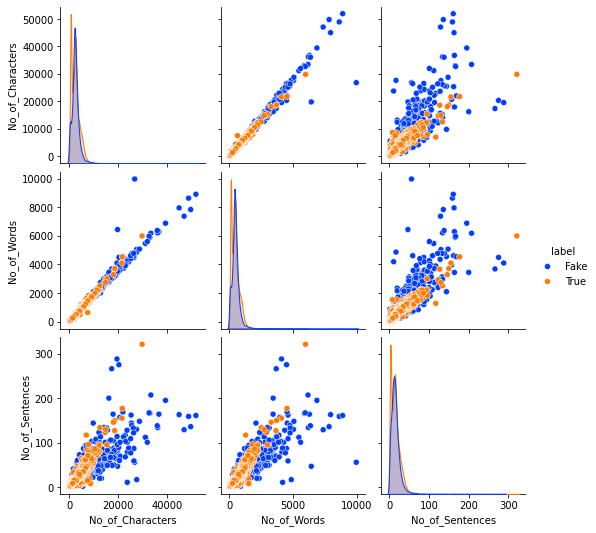

In [20]:
plt.figure(figsize=(12,8))
sns.pairplot(data=df, hue="label",palette="bright")
plt.show()

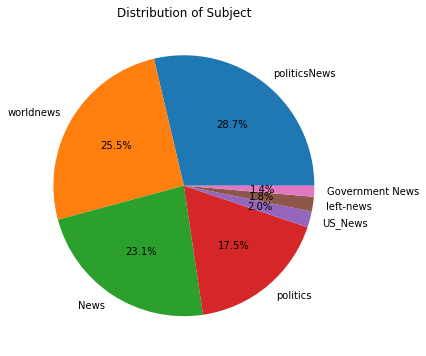

In [21]:
plt.figure(figsize=(12,6))
plt.pie(df['subject'].value_counts(), labels=df['subject'].value_counts().index, autopct='%1.1f%%')
plt.title('Distribution of Subject')
plt.show()

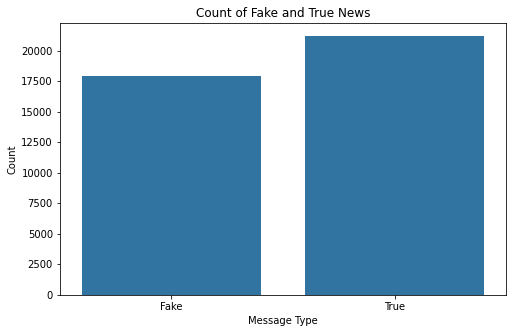

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df)
plt.title('Count of Fake and True News')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

In [23]:
def clean(text):
    text = re.sub(r'[^a-zA-Z\d]', ' ', text)
    text = re.sub(r'(https?://\S+|www\.\S+)', '', text)
    text = re.sub(r'\s+', ' ', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    doc = nlp(' '.join(tokens))
    lemmatized = [token.lemma_ for token in doc if token.lemma_ != '-PRON-']

    return ' '.join(lemmatized)


df['cleanded_text'] = df['Content'].apply(lambda x: clean(x.lower()))

In [24]:
df['label'] = df['label'].map({'Fake':0,'True':1})
df.head()

,title,text,subject,date,label,Content,No_of_Characters,No_of_Words,No_of_Sentences,cleanded_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,Donald Trump Sends Out Embarrassing New Year’...,2973,614,26,donald trump send embarrass new year eve messa...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,Drunk Bragging Trump Staffer Started Russian ...,1968,339,11,drunk bragging trump staffer start russian col...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,Sheriff David Clarke Becomes An Internet Joke...,3688,706,25,sheriff david clarke become internet joke thre...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,Trump Is So Obsessed He Even Has Obama’s Name...,2853,537,15,trump obsess even obama name code website imag...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,Pope Francis Just Called Out Donald Trump Dur...,2417,469,19,pope francis call donald trump christmas speec...


### **Étape 3: Division des Données et Vectorisation TF-IDF**

Cette étape combine deux opérations critiques:
1. **Division Train/Test**: 80% pour l'entraînement, 20% pour le test
2. **Vectorisation TF-IDF**: Conversion du texte en vecteurs numériques

Les algorithmes de machine learning opèrent sur des vecteurs numériques et non sur du texte brut. La vectorisation permet donc de transformer chaque document en un vecteur de dimension fixe, où chaque composante représente l’importance d’un terme. Parmi les différentes méthodes de vectorisation existantes, TF-IDF a été retenue car elle permet de représenter efficacement l’importance des mots dans un corpus. Contrairement à une simple fréquence de mots, TF-IDF réduit le poids des termes très fréquents mais peu informatifs (tels que les mots génériques) et met en valeur les termes discriminants, plus pertinents pour distinguer les articles. Cette approche est particulièrement adaptée aux tâches de classification de textes, notamment la détection de fake news, tout en restant simple, interprétable et peu coûteuse en calcul, ce qui en fait un bon compromis entre performance et complexité.

Concernant la division des données, le jeu de données utilisé contient environ 45 000 articles, ce qui permet une séparation fiable entre les ensembles d’entraînement et de test. Le choix d’une répartition 80 % / 20 % garantit que le modèle dispose d’un volume suffisant de données pour apprendre des représentations robustes, tout en conservant un ensemble de test suffisamment large et représentatif pour évaluer objectivement ses performances. Cette répartition est largement adoptée dans la littérature et constitue un bon équilibre entre apprentissage et évaluation pour des jeux de données de grande taille.

In [25]:
X = df[['cleanded_text']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train Shape :',X_train.shape)
print('X_test Shape :',X_test.shape)
print('y_train Shape :',y_train.shape)
print('y_test Shape :',y_test.shape)

X_train Shape : (31284, 1)
X_test Shape : (7821, 1)
y_train Shape : (31284,)
y_test Shape : (7821,)


In [26]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train['cleanded_text'])
X_test_tfidf = vectorizer.transform(X_test['cleanded_text'])

### **Étape 4: Entraînement des Modèles**


Cette étape consiste à entraîner plusieurs algorithmes de machine learning afin de comparer leurs performances dans le cadre de la classification des articles. Les modèles retenus sont la régression logistique, Naive Bayes, SVM et XGBoost. Ces algorithmes couvrent différentes approches abordées dans le cours, allant des modèles probabilistes et linéaires aux méthodes à large marge et aux techniques d’ensemble. Leur diversité permet d’analyser l’impact du choix du modèle sur les performances et la capacité de généralisation.

Ces modèles sont particulièrement bien adaptés au problème de détection de fake news, qui repose sur la classification de textes de grande dimension issus de la vectorisation TF-IDF. La régression logistique et le SVM sont efficaces pour les données textuelles creuses et de haute dimension, Naive Bayes est reconnu pour sa rapidité et son efficacité sur les tâches de classification de texte, tandis que XGBoost permet de capturer des relations plus complexes grâce à une combinaison d’arbres de décision. L’utilisation de ces modèles offre ainsi un cadre complet pour évaluer différentes stratégies d’apprentissage et identifier la plus performante pour ce problème.

In [27]:
results = []

def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average='binary'),
        "Recall": recall_score(y_test, y_test_pred, average='binary'),
        "F1-score": f1_score(y_test, y_test_pred, average='binary')
    }

#### 4.1- Régression logistique

Une recherche en grille a été mise en place afin d’optimiser les hyperparamètres de la régression logistique
et d’améliorer ses performances de classification. La régression logistique étant sensible au choix de ses hyperparamètres
, notamment au paramètre de régularisation C, cette étape permet d’identifier automatiquement la combinaison offrant le
meilleur compromis entre biais et variance. Les valeurs testées pour C [0.01,0.1, 1,10]
couvrent différents niveaux de régularisation, allant d’une régularisation forte à faible, afin d’évaluer leur impact sur
la capacité de généralisation du modèle.

Le choix de la pénalité L2 et du solveur lbfgs s’explique par leur stabilité et leur efficacité sur des données de grande
dimension issues de la vectorisation TF-IDF. De plus, des valeurs élevées pour max_iter [500,1000]sont utilisées afin 
d’assurer la convergence du modèle. La validation croisée à 5 plis
permet d’obtenir une estimation robuste des performances.

In [28]:
lr = LogisticRegression()

param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs'], 'max_iter': [500, 1000]}

grid = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring="f1_macro", n_jobs=-1)

grid.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'max_iter': [500, 1000],
                         'penalty': ['l2'], 'solver': ['lbfgs']},
             scoring='f1_macro')

In [29]:
best_lr = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'C': 10, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV score: 0.9893716395039981


In [30]:
results.append(evaluate_model(best_lr, "Logistic Regression",
                              X_train_tfidf, y_train,
                              X_test_tfidf, y_test))

#### 4.2- XGBoost

Les hyperparamètres du modèle XGBoost ont été choisis afin d’obtenir un bon équilibre entre performance et capacité de 
généralisation pour la tâche de classification binaire des articles. L’objectif binary:logistic est adapté à la détection
de fake news, car il permet de modéliser directement la probabilité d’appartenance à l’une des deux classes.
Les paramètres max_depth = 3 et min_child_weight = 3 limitent la complexité des arbres et réduisent le risque de 
surapprentissage, ce qui est particulièrement important dans un contexte de données textuelles de grande dimension.
Le taux d’apprentissage learning_rate = 0.1 permet une convergence progressive et stable du modèle, tandis que les
paramètres de sous-échantillonnage subsample = 0.7 et colsample_bytree = 0.5 introduisent de la diversité dans 
l’apprentissage et améliorent la robustesse du modèle. Enfin, le paramètre gamma = 0 autorise les divisions lorsque celles
-ci apportent un gain suffisant, favorisant ainsi une meilleure capacité de discrimination sans pénaliser excessivement 
l’apprentissage.

In [31]:
xgboost = model = XGBClassifier(objective = "binary:logistic" , subsample = 0.7 , min_child_weight = 3,
                                max_depth = 3 , learning_rate = 0.1 , gamma = 0 , colsample_bytree = 0.5,)
results.append(evaluate_model(xgboost, "XGBoost",
                              X_train_tfidf, y_train,
                              X_test_tfidf, y_test))

#### 4.3- SVM

Une recherche en grille a été effectuée pour optimiser les hyperparamètres du modèle SVM linéaire et améliorer ses 
performances de classification. Le SVM est particulièrement sensible au choix de certains hyperparamètres, notamment C,
qui contrôle la régularisation et donc le compromis entre biais et variance. Les valeurs testées pour C 
[0.01,0.1,1,10] couvrent différents niveaux de régularisation, allant d’une régularisation forte à faible, afin d’évaluer
leur impact sur la capacité de généralisation du modèle.

Le paramètre class_weight est exploré avec les options None et "balanced" pour gérer d’éventuels déséquilibres entre les
classes. La validation croisée stratifiée à 3 plis garantit que chaque
pli conserve la proportion des classes, offrant ainsi une évaluation robuste des performances. L’ensemble de ces réglages
permet à GridSearchCV d’identifier automatiquement la combinaison d’hyperparamètres la plus efficace, conduisant au
meilleur estimateur final svm_model.

In [32]:
param_grid_svm = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"],
    "loss": ["hinge"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_svm = GridSearchCV(estimator=LinearSVC(random_state=42), param_grid=param_grid_svm, scoring="f1", cv=cv, n_jobs=-1)

grid_svm.fit(X_train_tfidf, y_train)

svm_model = grid_svm.best_estimator_

In [33]:
results.append(evaluate_model(svm_model, "SVM",
                              X_train_tfidf, y_train,
                              X_test_tfidf, y_test))

#### 4.4- Multinomial Naive Bayes

Une recherche en grille a été réalisée pour optimiser les hyperparamètres du modèle Multinomial Naive Bayes et améliorer
ses performances de classification. Le paramètre alpha contrôle le lissage de Laplace, ce qui permet d’éviter les 
probabilités nulles pour des mots non observés dans le corpus d’entraînement. Les valeurs testées 
[0.001,0.01,0.1,1.0] couvrent différents niveaux de régularisation afin d’identifier le meilleur compromis entre biais 
et variance.

Le paramètre fit_prior, testé avec True et False, permet de décider si le modèle doit utiliser les probabilités a priori 
des classes ou les traiter de manière uniforme, ce qui peut être utile en cas de déséquilibre entre les classes. La 
validation croisée stratifiée à 5 plis garantit que chaque pli conserve la proportion des classes,
fournissant ainsi une estimation robuste des performances. Grâce à cette recherche, GridSearchCV sélectionne 
automatiquement la combinaison d’hyperparamètres optimale, conduisant au meilleur estimateur final nb_model.

In [34]:
param_grid_nb = {
    "alpha": [0.001, 0.01, 0.1, 1.0],
    "fit_prior": [True, False]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_nb = GridSearchCV(estimator=MultinomialNB(), param_grid=param_grid_nb, scoring="f1", cv=cv, n_jobs=-1)

grid_nb.fit(X_train_tfidf, y_train)

nb_model = grid_nb.best_estimator_
print(" Meilleurs paramètres NB:", grid_nb.best_params_)
print(" Meilleur score CV (F1):", grid_nb.best_score_)

 Meilleurs paramètres NB: {'alpha': 0.1, 'fit_prior': True}
 Meilleur score CV (F1): 0.9466452549115891


In [35]:
results.append(evaluate_model(nb_model, "Naive Bayes",
                              X_train_tfidf, y_train,
                              X_test_tfidf, y_test))

### **Étape 5: Évaluation et comparaison des modèles**

Cette étape vise à mesurer et comparer les performances des différents modèles entraînés. Pour ce faire, plusieurs
métriques telles que le score d'entraînement et de test, la précision, le recall et le F1-score sont calculées. La comparaison visuelle de ces métriques  via des barplots permet de mettre en évidence les forces et faiblesses relatives de chaque modèle et de 
sélectionner celui offrant le meilleur compromis pour la détection des fake news.

Par ailleurs, des matrices de confusion sont générées pour chaque modèle afin d’examiner en détail le nombre de
classifications correctes et incorrectes pour les classes Fake et True. Ces visualisations facilitent 
l’interprétation des résultats et permettent de détecter des biais ou déséquilibres dans la prédiction. L’approche 
combinée — comparaison des métriques globales et inspection des matrices de confusion — offre une évaluation complète
et robuste de la qualité de chaque modèle, guidant ainsi le choix du modèle final pour notre problème.

In [36]:
def plot_model_comparison(df, margin=0.002):
    metrics = df.columns[1:]
    x = range(len(df["Model"]))

    plt.figure(figsize=(14, 6))

    for i, metric in enumerate(metrics):
        plt.bar(
            [p + i*0.12 for p in x],
            df[metric],
            width=0.12,
            label=metric
        )

    plt.xticks([p + 0.3 for p in x], df["Model"])
    plt.ylabel("Score")

    min_val = df[metrics].min().min()
    max_val = df[metrics].max().max()
    plt.ylim(min_val - margin, max_val + margin)

    plt.title("Model Performance Comparison")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    



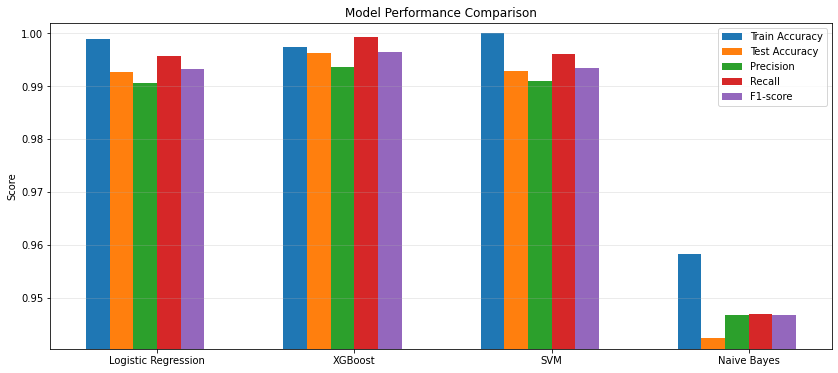

In [37]:
results_df = pd.DataFrame(results)
plot_model_comparison(results_df)

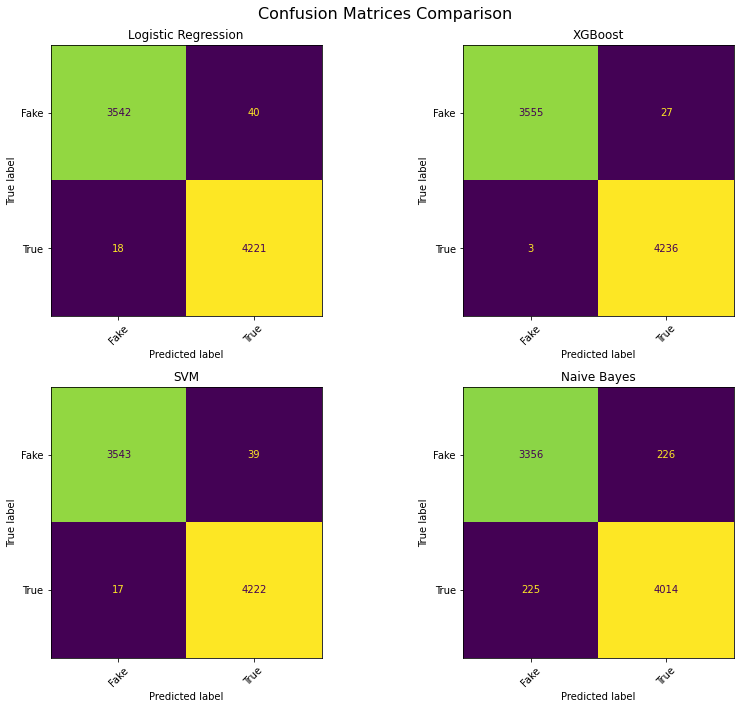

In [38]:
models = {
    "Logistic Regression": best_lr,
    "XGBoost": xgboost,
    "SVM": svm_model,
    "Naive Bayes": nb_model
}

n_cols = 2
n_rows = ceil(len(models) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()  

for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_tfidf,
        y_test,
        ax=ax,
        display_labels=['Fake', 'True'],
        xticks_rotation=45,
        colorbar=False
    )
    ax.set_title(name)

for i in range(len(models), len(axes)):
    axes[i].axis('off')

plt.suptitle("Confusion Matrices Comparison", fontsize=16)
plt.tight_layout()
plt.show()

### **Conclusion**

Ce projet de détection de fake news par apprentissage automatique démontre l'efficacité des méthodes de classification supervisée appliquées au traitement du langage naturel. En s'appuyant sur un dataset équilibré de 45 000 articles et une vectorisation TF-IDF, quatre algorithmes ont été comparés : Régression Logistique, SVM, XGBoost et Naive Bayes.
Les résultats révèlent que XGBoost obtient les meilleures performances en général. Sa matrice de confusion montre seulement 27 faux positifs et 3 faux négatifs, témoignant d'une capacité exceptionnelle à minimiser les erreurs de classification. Sa supériorité s'explique par son approche par ensemble d'arbres de décision qui capture efficacement les relations complexes dans les textes.
SVM et Régression Logistique affichent également d'excellentes performances. Leurs matrices de confusion révèlent respectivement 39 et 40 faux positifs, ainsi que 17 et 18 faux négatifs. Ces résultats confirment leur efficacité sur les données textuelles de haute dimension issues de TF-IDF, avec des scores de précision, rappel et F1-score supérieurs à 99%.
En revanche, Naive Bayes sous-performe significativement avec 94,5% de précision. Sa matrice de confusion expose une faiblesse majeure : 226 faux positifs et 225 faux négatifs, soit un taux d'erreur environ 10 fois supérieur aux autres modèles. Cette performance illustre que ses hypothèses d'indépendance conditionnelle ne sont pas adaptées aux dépendances linguistiques complexes présentes dans les articles d'actualité.
Ces résultats valident l'approche méthodologique adoptée et démontrent que l'automatisation de la détection de fake news est non seulement possible, mais hautement performante. Face à l'ampleur du volume d'informations diffusées quotidiennement, ces systèmes automatisés constituent une réponse technologique essentielle pour assister le fact-checking manuel et lutter contre la désinformation à grande échelle.
